<a href="https://colab.research.google.com/github/csorty/car/blob/main/kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


МЕТОД ЛОКТЯ: проверка k от 1 до 10
k = 1: инерция = 19953.77
k = 2: инерция = 9416.21
k = 3: инерция = 2110.41
k = 4: инерция = 2058.54
k = 5: инерция = 2007.60
k = 6: инерция = 461.71
k = 7: инерция = 434.73
k = 8: инерция = 434.73
k = 9: инерция = 421.36
k = 10: инерция = 412.39

✅ Оптимальное количество кластеров (метод локтя): 2



/tmp/ipykernel_9874/1181246131.py:117: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scat = ax.scatter(X[:, 0], X[:, 1], c='gray', s=30, cmap='viridis', alpha=0.6)


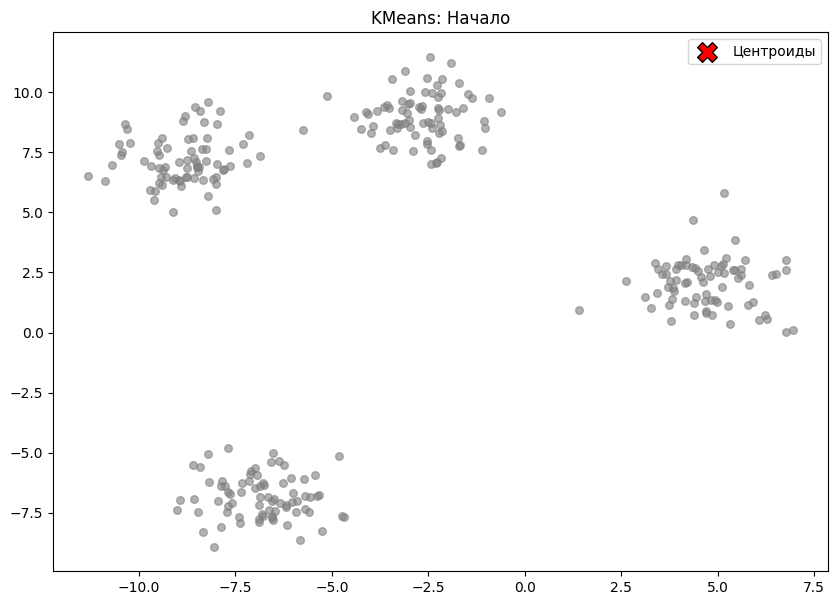

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from sklearn.datasets import make_blobs


class KMeans:
    def __init__(self, n_clusters=3, max_iter=100, tol=1e-4, random_state=None):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.labels = None

    def fit(self, X):
        if self.random_state:
            np.random.seed(self.random_state)

        n_samples, n_features = X.shape
        random_idx = np.random.choice(n_samples, self.n_clusters, replace=False)
        self.centroids = X[random_idx]

        for i in range(self.max_iter):
            distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
            self.labels = np.argmin(distances, axis=1)

            new_centroids = np.array(
                [X[self.labels == k].mean(axis=0) if np.any(self.labels == k) else self.centroids[k]
                 for k in range(self.n_clusters)])

            if np.all(np.linalg.norm(new_centroids - self.centroids, axis=1) < self.tol):
                break
            self.centroids = new_centroids

    def predict(self, X):
        distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
        return np.argmin(distances, axis=1)

    def inertia(self, X):
        return np.sum((X - self.centroids[self.labels]) ** 2)

    def fit_gen(self, X):

        if self.random_state:
            np.random.seed(self.random_state)

        n_samples, _ = X.shape
        random_idx = np.random.choice(n_samples, self.n_clusters, replace=False)
        self.centroids = X[random_idx].copy()

        for i in range(self.max_iter):

            distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
            self.labels = np.argmin(distances, axis=1)


            yield self.centroids, self.labels, f"Итерация {i + 1}: Привязка"


            new_centroids = np.array([
                X[self.labels == k].mean(axis=0) if np.any(self.labels == k) else self.centroids[k]
                for k in range(self.n_clusters)
            ])


            shift = np.linalg.norm(new_centroids - self.centroids, axis=1)
            converged = np.all(shift < self.tol)

            self.centroids = new_centroids

            yield self.centroids, self.labels, f"Итерация {i + 1}: Обновление центроидов"

            if converged:
                yield self.centroids, self.labels, "Сходимость достигнута!"
                break


def find_optimal_k_elbow(X, max_k=12, random_state=42):

    inertias = []
    k_range = range(1, max_k + 1)

    print(f"\n{'=' * 50}")
    print(f"МЕТОД ЛОКТЯ: проверка k от 1 до {max_k}")
    print(f"{'=' * 50}")

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=random_state)
        kmeans.fit(X)
        inertias.append(kmeans.inertia(X))
        print(f"k = {k}: инерция = {kmeans.inertia(X):.2f}")

    differences = []
    for i in range(1, len(inertias)):
        differences.append(inertias[i - 1] - inertias[i])

    elbow_index = np.argmax(differences)
    optimal_k = elbow_index + 2

    print(f"\n✅ Оптимальное количество кластеров (метод локтя): {optimal_k}")
    print(f"{'=' *50}\n")

    return inertias, optimal_k




X, _ = make_blobs(n_samples=300, centers=4, cluster_std=1.0, random_state=42)

inertias, optimal_k = find_optimal_k_elbow(X, max_k=10, random_state=42)

model = KMeans(n_clusters=optimal_k, random_state=42)
generator = model.fit_gen(X)

fig, ax = plt.subplots(figsize=(10, 7))
scat = ax.scatter(X[:, 0], X[:, 1], c='gray', s=30, cmap='viridis', alpha=0.6)
cent_scat = ax.scatter([], [], c='red', marker='X', s=200, edgecolors='black', label='Центроиды')
title = ax.set_title("KMeans: Начало")
ax.legend()


def update(data):
    centroids, labels, status = data
    scat.set_array(labels)
    cent_scat.set_offsets(centroids)

    ax.set_title(status)
    return scat, cent_scat


ani = FuncAnimation(fig, update, frames=generator, interval=800,
                    repeat=False, save_count=100, cache_frame_data=False)

plt.show()